# Prédiction du Verbal Learning — Pipeline de classification supervisée

**Objectif :** prédire la catégorie du *Verbal Learning* (VBL) — `bad` / `medium` / `good` —
à partir de variables neurophysiologiques et anatomiques (potentiels évoqués, latences, volumes...).

**Plan du notebook :**
1. Préprocessing (chargement, split, encodage, nettoyage, discrétisation, ACP exploratoire)
2. Modélisation — comparaison de plusieurs classifieurs
3. Modèles complémentaires (One-vs-Rest, arbre de décision) et analyse des résidus


# 1. Préprocessing

## 1.1 Imports

On importe :
- `pandas` / `numpy` pour la manipulation de données ;
- `seaborn` / `matplotlib` pour les visualisations ;
- `scikit-learn` pour le split train/test, la validation croisée, la recherche d'hyperparamètres
  (`GridSearchCV`), l'encodage, l'imputation, la standardisation et la réduction de dimension (PCA).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, learning_curve,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pd.set_option("display.precision", 3)

## 1.2 Chargement des données

Lecture du fichier Excel source (feuille `Total2`). Les différentes graphies de valeurs
manquantes rencontrées dans le fichier (`na`, `NaN`, `N/A`, ...) sont explicitement listées
pour être toutes reconnues comme `NaN` par pandas.


In [2]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()
raw_df.shape

(65, 18)

## 1.3 Split train / test — AVANT tout prétraitement

**Utilité :** en séparant train et test *avant* toute étape de nettoyage/encodage/imputation, on
garantit qu'aucune information du test (y compris la cible) ne peut influencer un choix fait sur
le train. C'est la condition de base pour obtenir, à la fin, une estimation honnête de la
performance du modèle sur des données jamais vues.

On sépare donc `X` (les 8 prédicteurs) de `y` (la cible `VBL`), puis on effectue le split
(90% train / 10% test).


In [3]:
TARGET_COLUMN = "VBL"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")

Cible : VBL
Train : 58 patients | Test : 7 patients


## 1.4 Encodage de la variable catégorielle `Hipp`

**Méthode utilisée : `OneHotEncoder`.** Elle transforme une variable catégorielle (ex. un statut
hippocampique) en plusieurs colonnes binaires (0/1), une par catégorie, ce qui est indispensable
pour la plupart des modèles de `scikit-learn` qui n'acceptent que des variables numériques.

**Utilité de fit/transform séparés :** l'encodeur est **fit uniquement sur `X_train`** puis
seulement **appliqué** (`transform`) sur `X_test`, avec `handle_unknown="ignore"` pour ignorer
sans erreur une catégorie rare qui n'apparaîtrait que dans le test. Cela évite que la composition
du test influence la définition des catégories.


In [4]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
12,-125.3,92.5,-21.6,-54.0,11.2,NaN,NaN,1.0,0.0,0.0
64,-48.4,33.7,-53.2,NaN,NaN,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,-73.1,NaN,NaN,1,81/81,0.0,0.0,1.0
33,0.0,168.0,-74.2,-11.0,0.0,98%,80/77,0.0,1.0,0.0
9,-105.0,79.3,-18.8,NaN,NaN,0.94,68/43,1.0,0.0,0.0


## 1.5 Nettoyage des données : suppression des colonnes trop incomplètes

**Utilité :** une colonne avec trop de valeurs manquantes apporte peu d'information et complique
l'imputation ; on la supprime plutôt que de risquer d'imputer des valeurs peu fiables.

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — on ne regarde jamais les valeurs du test pour décider quoi supprimer.


### 1.5.1 Taux de valeurs manquantes par variable (train)

In [5]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         60.345
OB         58.621
LRC        36.207
N400       36.207
P600        3.448
P300        3.448
LNC         3.448
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

### 1.5.2 Visualisation

Barplot des variables dont le taux de valeurs manquantes dépasse `threshold_view` (10%), avec une
ligne verticale marquant le seuil de suppression retenu (`threshold` = 40%).


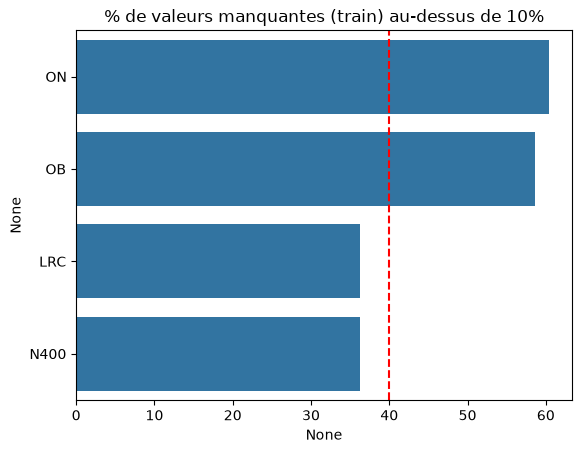

In [6]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")

### 1.5.3 Suppression effective des colonnes au-dessus du seuil

In [7]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape

Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((58, 8), (7, 8))

## 1.6 Passage des variables en valeurs absolues

In [8]:
# On ne transforme que les colonnes numériques
numeric_cols = X_train.select_dtypes(include="number").columns

X_train[numeric_cols] = X_train[numeric_cols].abs()
X_test[numeric_cols] = X_test[numeric_cols].abs()

X_train.head()

,P300,P600,LNC,N400,LRC,Hipp_NI,Hipp_ZE,Hipp_ZP
12,125.3,92.5,21.6,54.0,11.2,1.0,0.0,0.0
64,48.4,33.7,53.2,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,73.1,NaN,NaN,0.0,0.0,1.0
33,0.0,168.0,74.2,11.0,0.0,0.0,1.0,0.0
9,105.0,79.3,18.8,NaN,NaN,1.0,0.0,0.0


## 1.7 Retrait des lignes où la cible (`VBL`) est manquante

**Utilité :** on n'impute jamais la variable à prédire — il est impossible d'entraîner ou
d'évaluer un modèle sur une ligne dont on ne connaît pas la vraie réponse. On filtre donc
train et test séparément, chacun sur son propre masque de valeurs manquantes.


In [9]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train = X_train.loc[train_mask.index[train_mask]]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train.shape[0]} patients | Test final : {X_test.shape[0]} patients")

Lignes retirées (train, VBL manquant) : 4
Lignes retirées (test, VBL manquant)  : 0
Train final : 54 patients | Test final : 7 patients


## 1.8 Visualisation exploratoire : VBL en fonction de chaque variable (train)

**Utilité :** un simple nuage de points de la cible contre chaque prédicteur permet de repérer
visuellement d'éventuelles relations (linéaires ou non), des valeurs aberrantes, ou l'absence
totale de lien — une étape rapide avant de se lancer dans la modélisation.


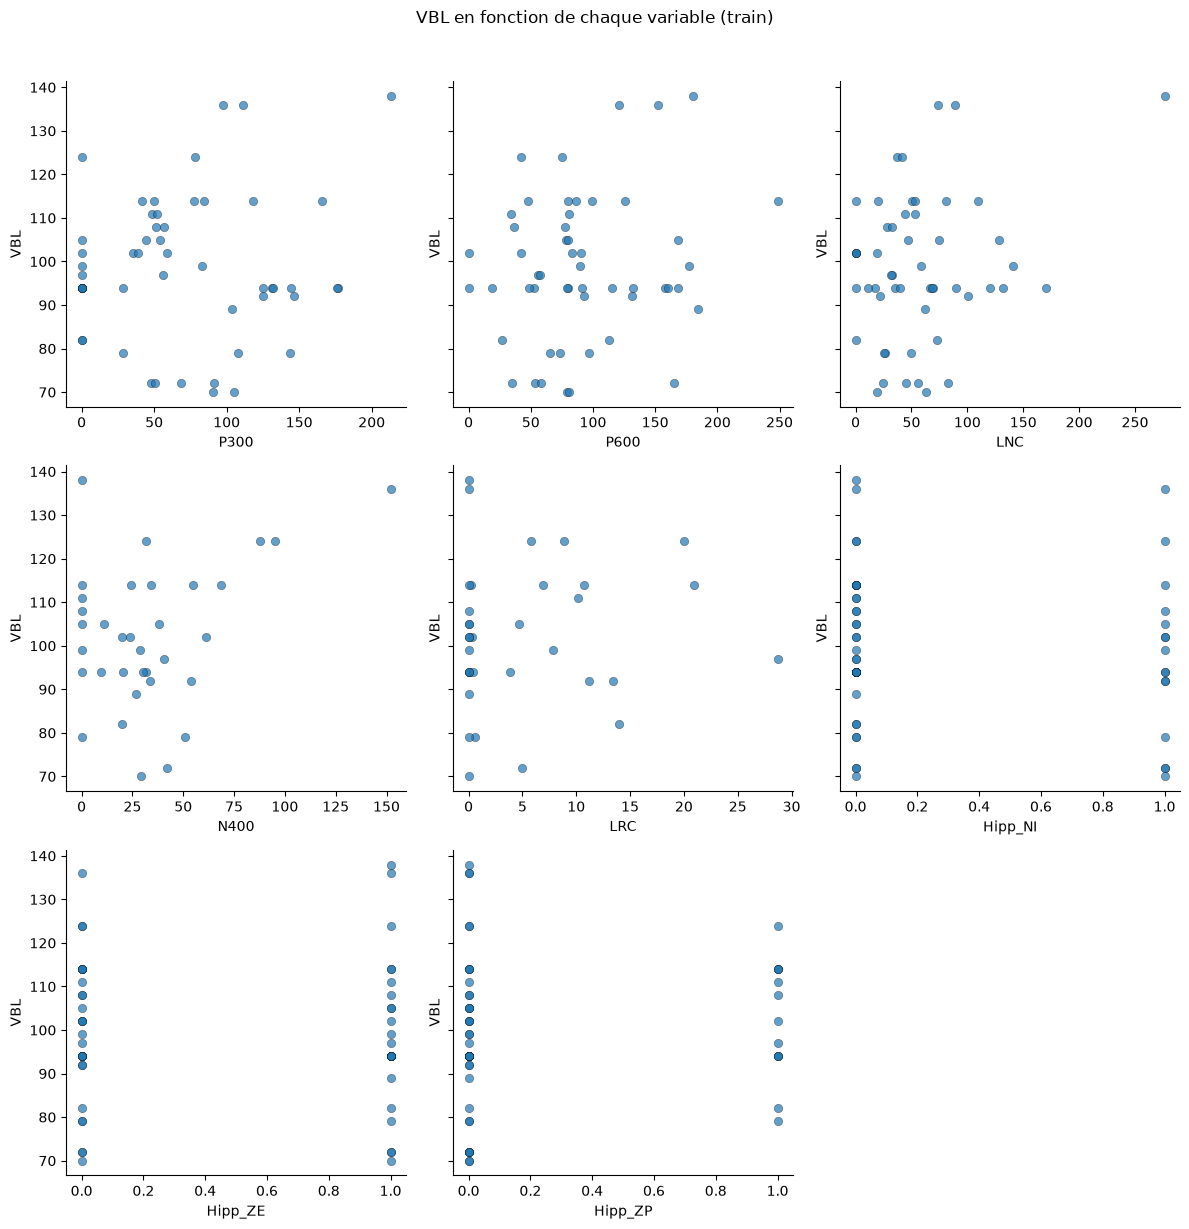

In [10]:
n_cols = 3
n_rows = int(np.ceil(len(X_train.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, X_train.columns):
    ax.scatter(X_train[feature], y_train, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("VBL")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(X_train.columns):]:
    ax.axis("off")

fig.suptitle("VBL en fonction de chaque variable (train)", y=1.02)
plt.tight_layout()
plt.show()

## 1.9 Discrétisation de la cible VBL

**Utilité :** VBL est ici une variable continue. On la transforme en une variable catégorielle à
3 classes (`bad`, `medium`, `good`) via des **terciles**, ce qui permet de reformuler le problème
en une tâche de **classification** (plus robuste ici qu'une régression, notamment avec un
échantillon de petite taille) et facilite l'interprétation clinique du résultat.

Les bornes des terciles sont calculées **uniquement sur `y_train`**, puis appliquées telles
quelles à `y_test` (pas de recalcul sur le test, pour éviter toute fuite d'information).


In [11]:
# y_train / y_test sont des Series (colonne VBL) : on les convertit en DataFrame
y_train_df = y_train.to_frame(name="VBL")
y_test_df = y_test.to_frame(name="VBL")

# Bornes calculées UNIQUEMENT sur le train (jamais sur le test, pour éviter une fuite)
bin_edges = [
    y_train_df["VBL"].min() - 1,
    y_train_df["VBL"].quantile(1 / 3),
    y_train_df["VBL"].quantile(2 / 3),
    y_train_df["VBL"].max() + 1,
]
labels = ["bad", "medium", "good"]

y_train_df["VBL_Category"] = pd.cut(x=y_train_df["VBL"], bins=bin_edges, labels=labels)

# On applique les mêmes bornes au test (pas de recalcul sur le test !)
y_test_df["VBL_Category"] = pd.cut(x=y_test_df["VBL"], bins=bin_edges, labels=labels)

## 1.10 Réduction de dimension : Analyse en Composantes Principales (ACP)

**Utilité de la PCA :** avec seulement 8 prédicteurs (potentiellement corrélés) pour un
échantillon de petite taille, réduire la dimension permet de limiter le risque de surapprentissage
et d'accélérer l'entraînement, tout en conservant l'essentiel de l'information (variance).

Cette PCA exploratoire sert uniquement à **choisir un nombre de composantes raisonnable** ; la
PCA "officielle" utilisée dans les pipelines de modélisation ci-dessous est re-fit indépendamment
à chaque pli de validation croisée (donc jamais sur les données du pli de validation).

`X_train` contient encore des valeurs manquantes à ce stade : un `KNNImputer` est utilisé pour
imputer temporairement les valeurs manquantes en s'appuyant sur les k plus proches voisins,
uniquement dans le but de pouvoir fitter cette PCA exploratoire.


### 1.10. Éboulis des valeurs propres

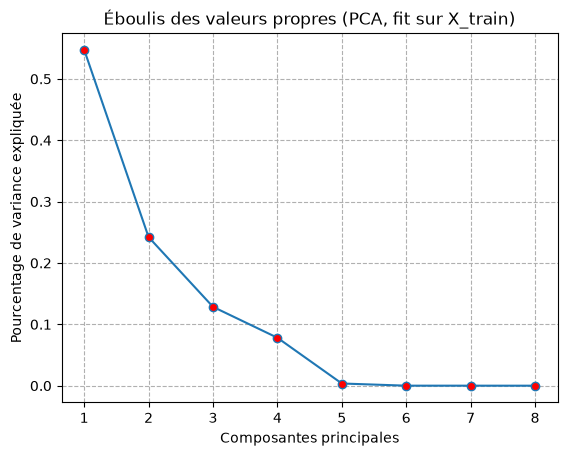

In [12]:
X_train_imputed_for_pca = KNNImputer().fit_transform(X_train)

pca_explore = PCA()
pca_explore.fit(X_train_imputed_for_pca)

explained_variance_ratio = pca_explore.explained_variance_ratio_

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o",
    markerfacecolor="r",
)
plt.xlabel("Composantes principales")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.ylabel("Pourcentage de variance expliquée")
plt.grid(linestyle="--")
plt.title("Éboulis des valeurs propres (PCA, fit sur X_train)")
plt.show()

# 2. Modélisation — comparaison de plusieurs classifieurs

**Modèles comparés (une seule boucle) :** Régression Logistique, Analyse Discriminante Linéaire (LDA),
SVM (SVC), Random Forest, Gradient Boosting, **One-vs-Rest (régression logistique)** et **Arbre de
décision (DecisionTree)**. Chaque modèle capture des types de relations différents (linéaires, à
marges maximales, à base d'arbres, stratégie multi-classes différente...), d'où l'intérêt de tous
les comparer sur les mêmes données plutôt que d'en choisir un a priori.

**Utilité de la `Pipeline` :** le `KNNImputer`, le `StandardScaler` et la `PCA` sont placés dans
la `Pipeline` (et non appliqués une fois pour toutes en amont) afin d'être **re-fit à chaque pli**
de la validation croisée — cela évite toute fuite de données du pli de validation vers le pli
d'entraînement.

Le test (`X_test`, `y_test`) reste intouché jusqu'à l'évaluation finale (section 2.3).

**Utilité du `GridSearchCV` multi-métriques :** chaque `GridSearchCV` est lancé une seule fois
avec plusieurs métriques (`Accuracy`, `F1_macro`, `Balanced_accuracy`) ; on récupère toutes les
métriques du meilleur jeu de paramètres directement depuis `cv_results_`, sans relancer une
seconde cross-validation (plus rapide, et cohérence garantie entre les métriques rapportées).

**Sélection finale :** on ne retient plus un seul "meilleur modèle", mais les **3 meilleurs**
(classés sur la CV du train), afin de les comparer plus en détail sur le test, les matrices de
confusion, la learning curve et l'importance des features (section 2.3 et suivantes).


## 2.1 Grille de recherche et validation croisée pour chaque modèle

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")

X = X_train
y = y_train_df["VBL_Category"]

# StratifiedKFold : conserve la proportion de chaque classe (bad/medium/good) dans chaque pli, important avec un petit échantillon
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
imputer = KNNImputer()

param_grids = {

    "Logistic Regression": (
        LogisticRegression(max_iter=10000),
        {
            "model__C": [0.001, 0.01, 0.1, 1],
            "model__penalty": ["l2"],
        },
    ),

    "LDA": (
        LinearDiscriminantAnalysis(),
        {
            "model__solver": ["svd", "lsqr"],
        },
    ),

    "SVC": (
        SVC(),
        {
            "model__C": [0.001, 0.01, 0.1, 1],
            "model__gamma": ["scale", "auto"],
            "model__kernel": ["rbf", "linear"],
        },
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [2, 4, 8],
        },
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [50, 100],
            "model__max_depth": [1, 2, 3],
            "model__learning_rate": [0.01, 0.1],
        },
    ),

    "OneVsRest": (
        OneVsRestClassifier(LogisticRegression(max_iter=1000)),
        {
            "model__estimator__C": [0.001, 0.01, 0.1, 1],
            "model__estimator__penalty": ["l2"],
            "model__estimator__solver": ["lbfgs"],
        },
    ),

    "Decision Tree": (
        DecisionTreeClassifier(random_state=42),
        {
            "model__max_depth": [1, 2, 3, None],
            "model__min_samples_leaf": [1, 2, 4, 8],
            "model__criterion": ["gini", "entropy"],
        },
    ),
}

scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Balanced_accuracy": "balanced_accuracy",
}

models = {}
results = []

for name, (estimator, grid) in param_grids.items():

    pipeline = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.90)),
        ("model", estimator),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring=scoring,
        refit="F1_macro",  # le modèle final est re-fit sur tout le train avec les meilleurs hyperparamètres
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X, y)

    models[name] = grid_search.best_estimator_

    best_idx = grid_search.best_index_
    cvres = grid_search.cv_results_

    results.append({
        "Model": name,
        "Accuracy_mean": cvres["mean_test_Accuracy"][best_idx],
        "F1_macro_mean": cvres["mean_test_F1_macro"][best_idx],
        "Balanced_accuracy_mean": cvres["mean_test_Balanced_accuracy"][best_idx],
        "Best params": grid_search.best_params_,
    })

    print(
        f"{name} : meilleurs paramètres = "
        f"{grid_search.best_params_} "
        f"(F1_macro = {cvres['mean_test_F1_macro'][best_idx]:.3f})"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Logistic Regression : meilleurs paramètres = {'model__C': 0.01, 'model__penalty': 'l2'} (F1_macro = 0.253)
LDA : meilleurs paramètres = {'model__solver': 'svd'} (F1_macro = 0.238)
SVC : meilleurs paramètres = {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'} (F1_macro = 0.270)
Random Forest : meilleurs paramètres = {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100} (F1_macro = 0.353)
Gradient Boosting : meilleurs paramètres = {'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__n_estimators': 100} (F1_macro = 0.301)
OneVsRest : meilleurs paramètres = {'model__estimator__C': 1, 'model__estimator__penalty': 'l2', 'model__estimator__solver': 'lbfgs'} (F1_macro = 0.280)
Decision Tree : meilleurs paramètres = {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 2} (F1_macro = 0.377)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,Logistic Regression,0.500,0.253,0.356,"{'model__C': 0.01, 'model__penalty': 'l2'}"
1,Random Forest,0.482,0.353,0.383,"{'model__max_depth': 3, 'model__min_samples_le..."
2,Decision Tree,0.447,0.377,0.393,"{'model__criterion': 'entropy', 'model__max_de..."
3,SVC,0.445,0.270,0.328,"{'model__C': 1, 'model__gamma': 'scale', 'mode..."
4,Gradient Boosting,0.407,0.301,0.327,"{'model__learning_rate': 0.1, 'model__max_dept..."
5,OneVsRest,0.393,0.280,0.310,"{'model__estimator__C': 1, 'model__estimator__..."
6,LDA,0.338,0.238,0.269,{'model__solver': 'svd'}


## 2.2 Visualisation comparative des modèles

Comparaison de l'accuracy moyenne (validation croisée, train uniquement) entre les **7 modèles**
testés, avec une ligne de référence correspondant à un classifieur aléatoire pour 3 classes
équilibrées (1/3). Les barres vertes signalent les modèles au-dessus du hasard, les rouges les
modèles en dessous.


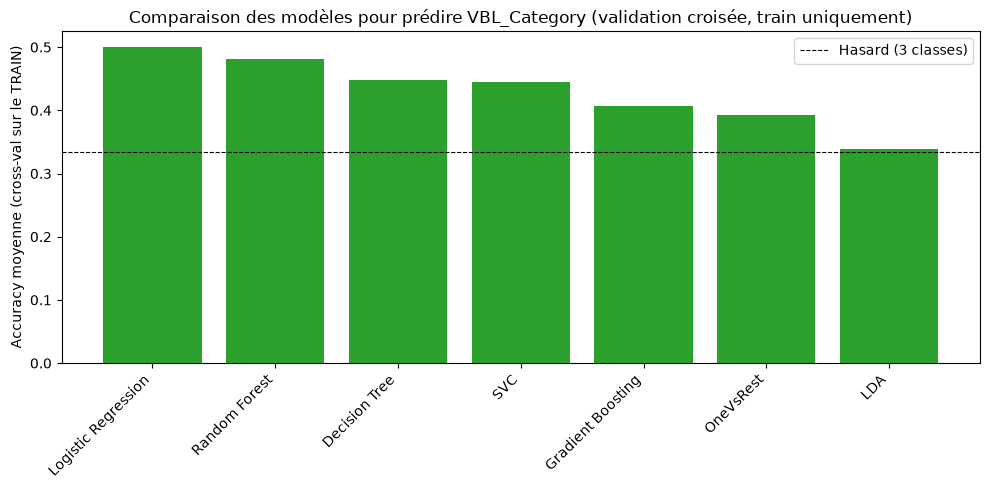

In [14]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if acc >= 1/3 else "#d62728" for acc in results_df["Accuracy_mean"]]
plt.bar(results_df["Model"], results_df["Accuracy_mean"], color=colors)

# Ligne de référence : accuracy d'un classifieur "au hasard" pour 3 classes équilibrées
plt.axhline(1/3, color="black", linewidth=0.8, linestyle="--", label="Hasard (3 classes)")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy moyenne (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN}_Category (validation croisée, train uniquement)")
plt.legend()
plt.tight_layout()
plt.show()

## 2.3 Sélection des 3 meilleurs modèles et évaluation UNIQUE sur le test

**Utilité :** les modèles sont classés selon leur performance en validation croisée **sur le
train** uniquement (pas d'accès au test avant ce stade). On retient les **3 meilleurs** (au lieu
d'un seul), chacun ensuite entraîné une seule fois sur l'intégralité du train, puis évalué **une
seule fois** sur le test — la seule mesure qui compte réellement pour juger la performance hors
échantillon, non biaisée par la sélection de modèle.


In [15]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

N_TOP = 3
top_models_names = results_df.head(N_TOP)["Model"].tolist()
print(f"Modèles retenus (top {N_TOP} sur la CV train) : {top_models_names}")

# Données de test
y_test_cat = y_test_df["VBL_Category"]

test_summaries = []
fitted_models = {}

for name in top_models_names:
    pipeline = models[name]
    pipeline.fit(X_train, y)  # entraînement sur tout le train
    fitted_models[name] = pipeline

    y_pred_test = pipeline.predict(X_test)

    test_summaries.append({
        "Modèle": name,
        "Accuracy (test)": round(accuracy_score(y_test_cat, y_pred_test), 3),
        "F1_macro (test)": round(f1_score(y_test_cat, y_pred_test, average="macro"), 3),
        "Balanced accuracy (test)": round(balanced_accuracy_score(y_test_cat, y_pred_test), 3),
        "Accuracy CV (train)": round(
            results_df.loc[results_df["Model"] == name, "Accuracy_mean"].iloc[0], 3
        ),
    })

summary_test_top3 = pd.DataFrame(test_summaries)
display(summary_test_top3)


Modèles retenus (top 3 sur la CV train) : ['Logistic Regression', 'Random Forest', 'Decision Tree']


,Modèle,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,Logistic Regression,0.286,0.148,0.222,0.500
1,Random Forest,0.286,0.148,0.222,0.482
2,Decision Tree,0.143,0.095,0.111,0.447


## 2.4 Matrices de confusion — train vs test (3 meilleurs modèles)

**Utilité :** la matrice de confusion détaille, classe par classe, où chaque modèle se trompe (par
exemple, confond-il surtout `medium` avec `bad`, ou avec `good` ?). Comparer train et test permet
aussi de détecter un éventuel surapprentissage (très bonne performance sur le train, nettement
moins bonne sur le test) — et de comparer ce comportement entre les 3 modèles retenus.


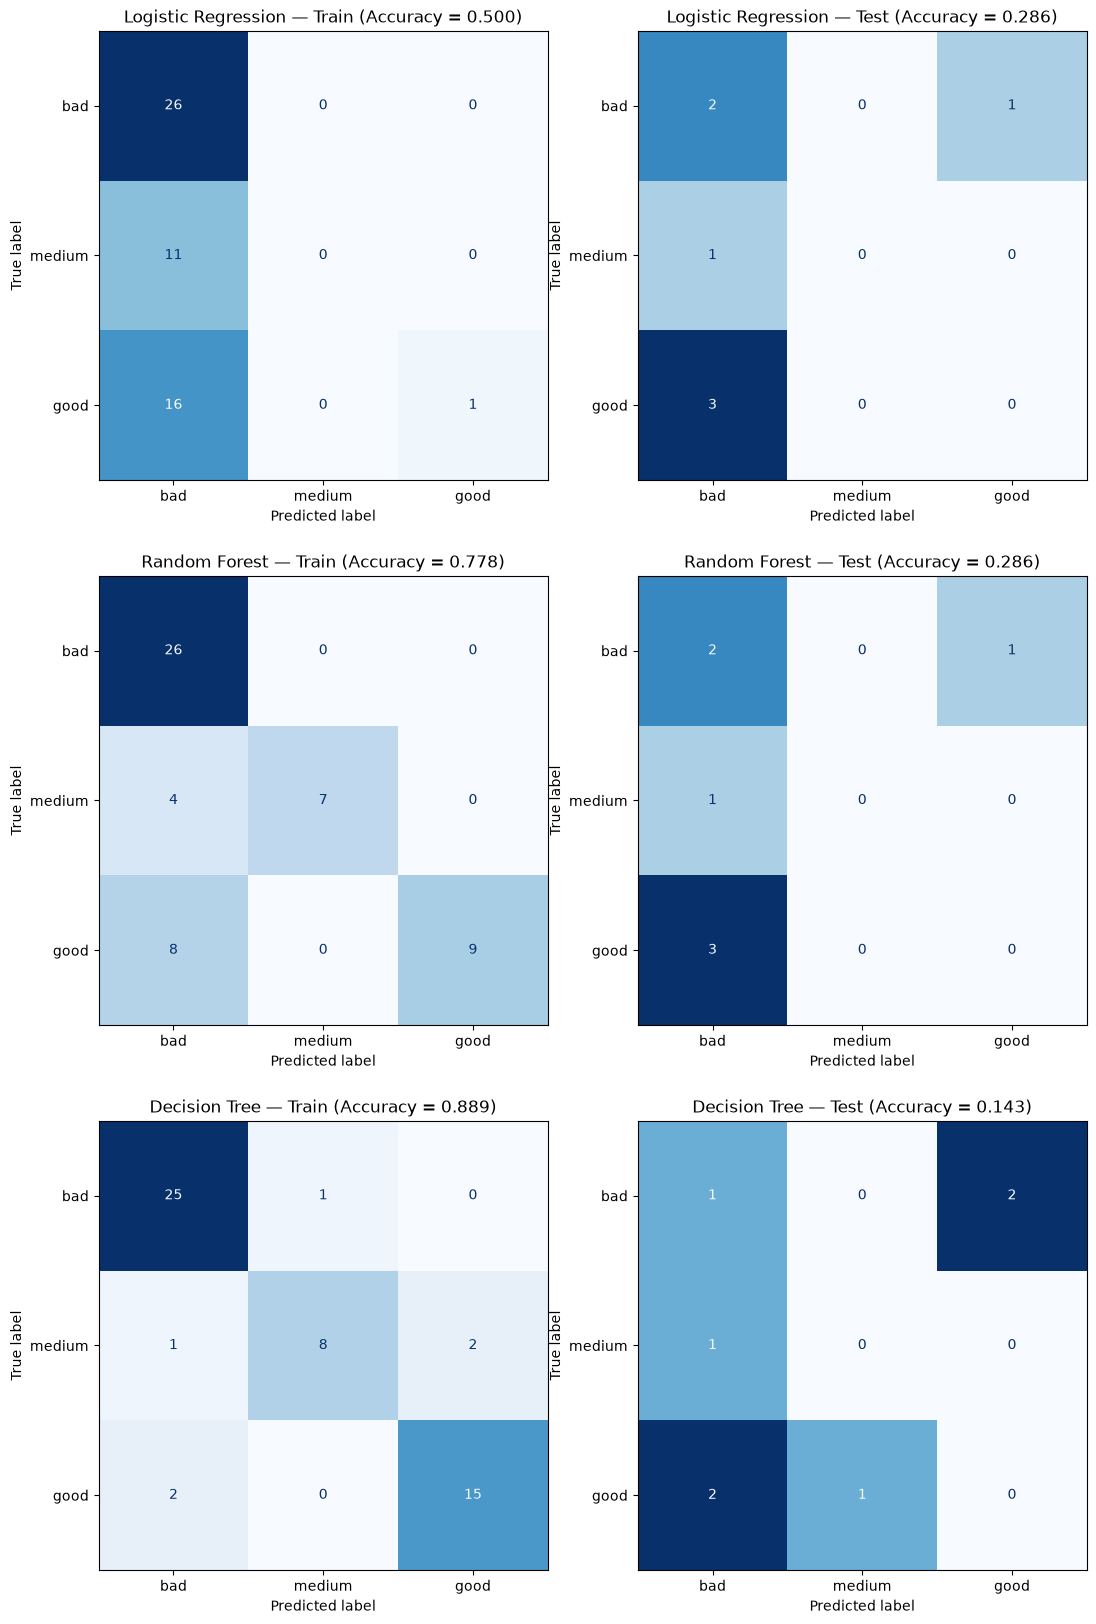

In [16]:
fig, axes = plt.subplots(len(top_models_names), 2, figsize=(11, 5.5 * len(top_models_names)))
if len(top_models_names) == 1:
    axes = axes.reshape(1, 2)

for row, name in enumerate(top_models_names):
    pipeline = fitted_models[name]

    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    train_accuracy = accuracy_score(y, y_pred_train)
    test_accuracy = accuracy_score(y_test_cat, y_pred_test)

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred_train,
        labels=["bad", "medium", "good"],
        cmap="Blues",
        ax=axes[row, 0],
        colorbar=False,
    )
    axes[row, 0].set_title(f"{name} — Train (Accuracy = {train_accuracy:.3f})")

    ConfusionMatrixDisplay.from_predictions(
        y_test_cat,
        y_pred_test,
        labels=["bad", "medium", "good"],
        cmap="Blues",
        ax=axes[row, 1],
        colorbar=False,
    )
    axes[row, 1].set_title(f"{name} — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()


## 2.5 Learning curves des 3 modèles retenus

**Utilité :** la *learning curve* montre l'évolution de l'accuracy (entraînement et validation
croisée interne au train) en fonction de la taille de l'échantillon d'entraînement. Elle permet
de diagnostiquer si un modèle souffre d'un **manque de données** (les deux courbes ne se
rejoignent pas et continuent de progresser) ou d'un **surapprentissage** (écart persistant entre
train et validation) — et de comparer ce diagnostic entre les 3 modèles retenus, côte à côte.


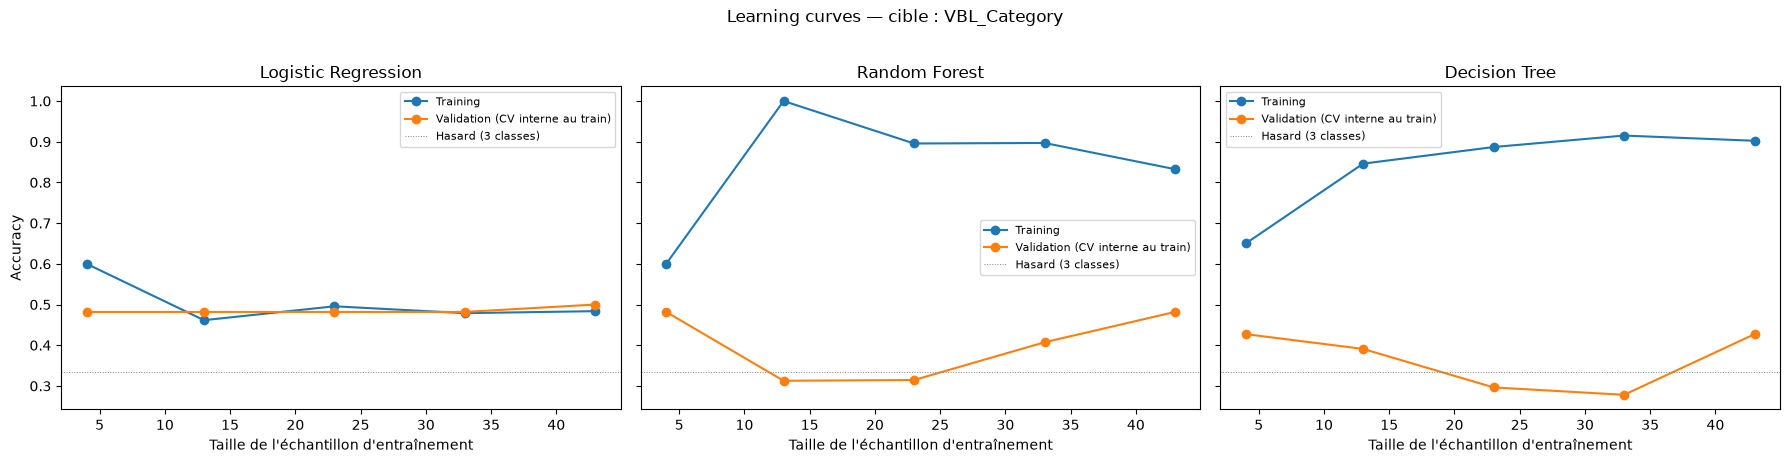

Cible prédite : VBL_Category (bad / medium / good)
Échantillon   : 54 (train) / 7 (test)

Classement des modèles (CV sur le train) :
              Model  Accuracy_mean  F1_macro_mean  Balanced_accuracy_mean                                                                                        Best params
Logistic Regression          0.500          0.253                   0.356                                                         {'model__C': 0.01, 'model__penalty': 'l2'}
      Random Forest          0.482          0.353                   0.383                  {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
      Decision Tree          0.447          0.377                   0.393            {'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 2}
                SVC          0.445          0.270                   0.328                                {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
  

In [17]:
fig, axes = plt.subplots(1, len(top_models_names), figsize=(6 * len(top_models_names), 4.5), sharey=True)
if len(top_models_names) == 1:
    axes = [axes]

for ax, name in zip(axes, top_models_names):
    pipeline = fitted_models[name]

    train_sizes, train_scores, val_scores = learning_curve(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
    )

    ax.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
    ax.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
    ax.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
    ax.set_xlabel("Taille de l'échantillon d'entraînement")
    ax.set_title(f"{name}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Accuracy")
fig.suptitle(f"Learning curves — cible : {TARGET_COLUMN}_Category", y=1.02)
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance des 3 modèles retenus sur le test (jamais vu avant) :")
print(summary_test_top3.to_string(index=False))


## 2.6 Importance des features (permutation importance)

**Utilité de la méthode :** contrairement à `coef_` ou `feature_importances_`, qui ne sont pas
disponibles pour tous les modèles (ex. SVC à noyau `rbf`) et qui, ici, s'exprimeraient de toute
façon dans l'espace des **composantes principales** (peu interprétable cliniquement), la
**permutation importance** fonctionne avec n'importe quel modèle et se calcule directement sur
les **variables originales** (`P300`, `P600`, `Hipp`...), en mélangeant aléatoirement chaque
colonne de `X_test` et en mesurant la chute de performance (`F1_macro`) qui en résulte. Plus la
chute est grande, plus la variable est importante pour ce modèle.


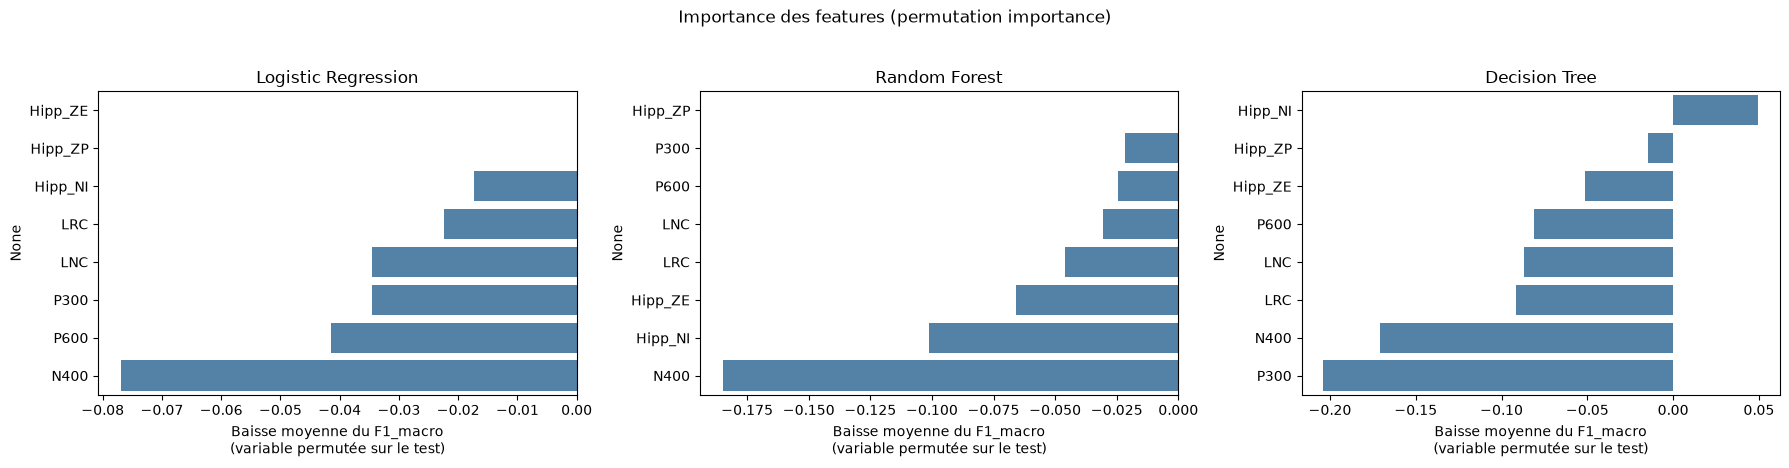

In [18]:
fig, axes = plt.subplots(1, len(top_models_names), figsize=(6 * len(top_models_names), 4.5))
if len(top_models_names) == 1:
    axes = [axes]

feature_names = X_test.columns
importances_by_model = {}

for ax, name in zip(axes, top_models_names):
    pipeline = fitted_models[name]

    perm_result = permutation_importance(
        pipeline,
        X_test,
        y_test_cat,
        scoring="f1_macro",
        n_repeats=30,
        random_state=42,
        n_jobs=1,
    )

    feature_scores = pd.Series(
        perm_result.importances_mean, index=feature_names
    ).sort_values(ascending=False)
    importances_by_model[name] = feature_scores

    sns.barplot(x=feature_scores.values, y=feature_scores.index, ax=ax, color="steelblue")
    ax.set_title(f"{name}")
    ax.set_xlabel("Baisse moyenne du F1_macro\n(variable permutée sur le test)")

fig.suptitle("Importance des features (permutation importance)", y=1.03)
plt.tight_layout()
plt.show()


# . Annexe : lecture des composantes principales

Rappel exploratoire (indépendant du choix de modèle) : contribution des variables originales aux
composantes principales 2 et 3 de la PCA exploratoire (section 1.10), utile pour interpréter ce
que "capturent" ces axes au-delà de la performance des modèles.


,PC2,PC3
P300,59.67,4.80
P600,35.59,32.27
LNC,4.68,58.27
N400,0.04,4.65
LRC,0.02,0.00
Hipp_NI,0.00,0.00
Hipp_ZE,0.00,0.00
Hipp_ZP,0.00,0.00


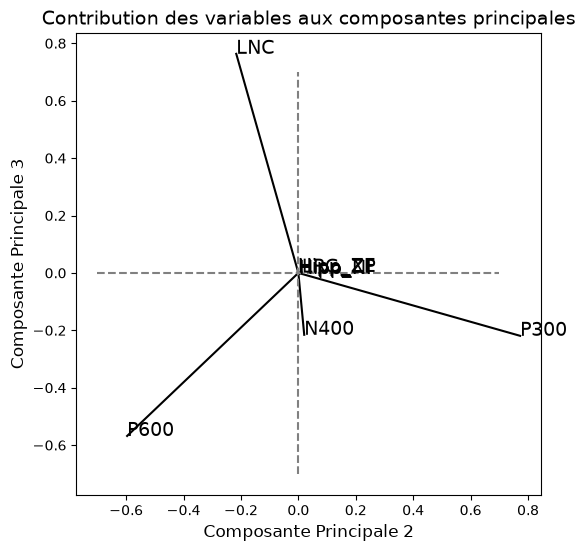

In [19]:
feature_names = X.columns

# Loadings / coordonnées des variables sur PC2 et PC3
pcs = pca_explore.components_[1:3, :]

loadings = pd.DataFrame(
    pcs.T,
    index=feature_names,
    columns=["PC2", "PC3"]
)

# Contributions en % de chaque variable à chaque composante
contrib = (loadings**2).div((loadings**2).sum(axis=0), axis=1) * 100
display(contrib.round(2))

# Graphique
fig, ax = plt.subplots(figsize=(6, 6))

for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
    ax.plot([0, x], [0, y], color='k')
    ax.text(x, y, feature_names[i], fontsize=14)

ax.plot([-0.7, 0.7], [0, 0], color='grey', ls='--')
ax.plot([0, 0], [-0.7, 0.7], color='grey', ls='--')

ax.set_xlabel("Composante Principale 2", fontsize=12)
ax.set_ylabel("Composante Principale 3", fontsize=12)
ax.set_title("Contribution des variables aux composantes principales", fontsize=14)
plt.show()